In [9]:
import pandas as pd, re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score
from joblib import Parallel, delayed
import joblib

In [10]:
aspects  = ['Overall', 'Value', 'Rooms', 'Location', 'Cleanliness', 'Front Desk', 'Service', 'Business Service']
rows = []
with open('00040-00000001.dat',encoding='utf-8', errors='replace') as f:
    next(f)
    for line in f:
        p = line.rstrip('\n').split(',')
        rows.append([p[0],p[1]]+[int(x) for x in p[-8:]])

ratings = pd.DataFrame(rows,columns=['Hotel', 'User'] + aspects)



In [11]:
rx = re.compile(r'^(\d+),(.*?),(\d\d/\d\d/\d{4}),(.*)$')
texts = [] 
for fn in ['00040-00000002.dat','00040-00000003.dat','00040-00000004.dat']:
    with open(fn,encoding='utf-8',errors='replace') as f:
        next(f)
        texts += [rx.match(l.rstrip('\n')).groups() for l in f]
text = pd.DataFrame(texts,columns=['hotel','user','date','text'])



In [12]:
df = pd.concat([ratings,text[['date','text']]],axis=1)
df = df[df['Overall']>0]
df = df[df['text'].str.split().str.len()>=20]
print(df.shape)

(173420, 12)


Overall        0.000
Value          0.243
Rooms          0.232
Location       0.425
Cleanliness    0.232
Service        0.248
dtype: float64


<Axes: xlabel='Overall'>

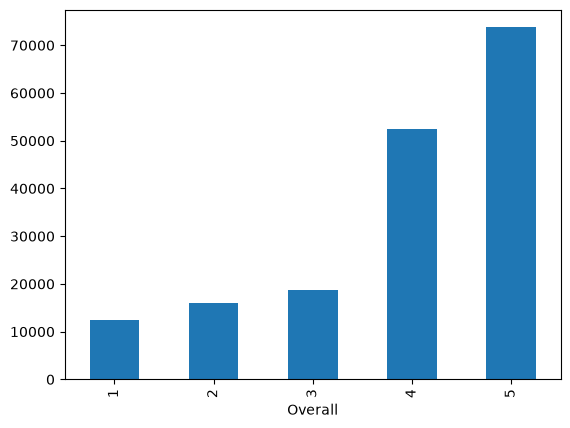

In [13]:
aspects_used = ['Overall','Value','Rooms','Location','Cleanliness','Service']
print((df[aspects_used]==-1).mean().round(3))
df['Overall'].value_counts().sort_index().plot(kind='bar')

In [14]:
small = df.sample(60000,random_state=42)
train, test = train_test_split(small,test_size=0.2,random_state=42)

In [15]:
vec = CountVectorizer(ngram_range=(1,2),min_df=5,max_features=200000)
x_train = vec.fit_transform(train['text'])
x_test = vec.transform(test['text'])

In [16]:
def polarity(r):
    return 0 if r <= 2 else (1 if r == 3 else 2)

def run(a, task, name):
    tr = (train[a] != -1).values
    te = (test[a] != -1).values
    y_tr, y_te = train.loc[tr, a], test.loc[te, a]
    if task == 'polarity':
        y_tr, y_te = y_tr.map(polarity), y_te.map(polarity)
    model = LinearSVC(class_weight='balanced', max_iter=2000) if name == 'SVM' else MultinomialNB()
    model.fit(x_train[tr], y_tr)
    pred = model.predict(x_test[te])
    return [a, task, name, accuracy_score(y_te, pred), f1_score(y_te, pred, average='macro')]

jobs = [(a, t, n) for a in aspects_used for t in ['stars', 'polarity'] for n in ['SVM', 'NB']]
results = Parallel(n_jobs=-1)(delayed(run)(*j) for j in jobs)
res = pd.DataFrame(results, columns=['aspect','task','model','accuracy','macro_f1'])
print(res.round(3))

/home/rohitpujari/ml312/lib/python3.12/site-packages/sklearn/svm/_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/rohitpujari/ml312/lib/python3.12/site-packages/sklearn/svm/_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/rohitpujari/ml312/lib/python3.12/site-packages/sklearn/svm/_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/rohitpujari/ml312/lib/python3.12/site-packages/sklearn/svm/_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/rohitpujari/ml312/lib/python3.12/site-packages/sklearn/svm/_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/rohitpujari/ml312/lib/python3.12/site-packages/sklearn/svm/_base.py:1295: Convergenc

         aspect      task model  accuracy  macro_f1
0       Overall     stars   SVM     0.597     0.539
1       Overall     stars    NB     0.642     0.577
2       Overall  polarity   SVM     0.858     0.706
3       Overall  polarity    NB     0.854     0.719
4         Value     stars   SVM     0.481     0.439
5         Value     stars    NB     0.534     0.487
6         Value  polarity   SVM     0.782     0.638
7         Value  polarity    NB     0.804     0.665
8         Rooms     stars   SVM     0.505     0.451
9         Rooms     stars    NB     0.544     0.481
10        Rooms  polarity   SVM     0.773     0.624
11        Rooms  polarity    NB     0.779     0.627
12     Location     stars   SVM     0.534     0.316
13     Location     stars    NB     0.581     0.282
14     Location  polarity   SVM     0.804     0.481
15     Location  polarity    NB     0.812     0.486
16  Cleanliness     stars   SVM     0.564     0.441
17  Cleanliness     stars    NB     0.597     0.442
18  Cleanlin

In [17]:
models = {}
for a in aspects_used:
    tr = (train[a] != -1).values
    m = LinearSVC(class_weight='balanced', max_iter=5000)
    m.fit(x_train[tr], train.loc[tr, a].map(polarity))
    models[a] = m

/home/rohitpujari/ml312/lib/python3.12/site-packages/sklearn/svm/_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/rohitpujari/ml312/lib/python3.12/site-packages/sklearn/svm/_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/rohitpujari/ml312/lib/python3.12/site-packages/sklearn/svm/_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [29]:
labels = {0: 'negative', 1: 'neutral', 2: 'positive'}

def predict_review(text):
    text = text.replace(',', ';')
    X = vec.transform([text])
    return {a: labels[models[a].predict(X)[0]] for a in aspects_used}

print(predict_review("The room was dirty and the staff were unfriendly. The location was inconvenient and overpriced."))

{'Overall': 'negative', 'Value': 'negative', 'Rooms': 'negative', 'Location': 'positive', 'Cleanliness': 'negative', 'Service': 'negative'}


In [19]:
joblib.dump((vec,models), 'absa_model.joblib')

['absa_model.joblib']